<a href="https://colab.research.google.com/github/cleanesantos/portfolio-cleane/blob/main/Trabalho_1_Aprendizado_de_M%C3%A1quina_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#### **Trabalho 1 - Aprendizado de Máquina - Decision Tree - Base de dados Diabetes**

Sumário:

---


1) **Descrição da base e variáveis (entendimento dos dados)**
2) **Estratégias de Pré-processamento, Imputação e Balanceamento dos Dados**
3) **Análise Descritiva dos dados**
4) **Preparação dos dados para modelagem**
5) **Treinamento e ajuste de hiperparâmetros**
6) **Avaliação e validação do modelo**
7) **Interpretação e análise dos resultados**
8) **Conclusão**


### **1) Descrição da base e variáveis (entendimento dos dados)**

### **Banco de dados de diabetes dos índios Pima**

**Contexto:** Este conjunto de dados é originário do Instituto Nacional de Diabetes e Doenças Digestivas e Renais. O objetivo do conjunto de dados é prever, de forma diagnóstica, se um paciente tem ou não diabetes, com base em determinadas medidas diagnósticas incluídas no conjunto de dados. Diversas restrições foram impostas à seleção dessas instâncias de um banco de dados maior. Em particular, todos os pacientes aqui são mulheres com pelo menos 21 anos de idade e de ascendência indígena Pima.


 **Dicionário de Variáveis — Pima Indians Diabetes Database**

| Variável | Descrição | Unidade / Tipo | Observações |
|-----------|------------|----------------|--------------|
| **Pregnancies** | Número de vezes que a paciente engravidou | Numérica (inteiro) | Pode variar de 0 a 17 |
| **Glucose** | Concentração plasmática de glicose em 2 horas em um teste oral de tolerância à glicose | mg/dL | Valor 0 indica dado ausente |
| **BloodPressure** | Pressão arterial diastólica | mm Hg | Valor 0 indica dado ausente |
| **SkinThickness** | Espessura da prega cutânea do tríceps | mm | Valor 0 indica dado ausente |
| **Insulin** | Insulina sérica de 2 h | μU/mL | Valor 0 indica dado ausente |
| **BMI** | Índice de massa corporal (peso / altura²) | kg/m² | Valor 0 indica dado ausente |
| **DiabetesPedigreeFunction** | Função de pedigree de diabetes (histórico familiar) | Adimensional | Mede predisposição genética |
| **Age** | Idade da paciente | Anos | Mínimo: 21  Máximo: 81 |
| **Outcome** | Resultado do teste de diagnóstico | Binária (0 = não diabética; 1 = diabética) | 268 de 768 registros são positivos |


In [ ]:
# ========================= 0. IMPORTS & CONFIG =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

# Reprodutibilidade
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

# Caminho do CSV
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Trabalho 1 - Aprendizado de Máquina /diabetes.csv'

# Carregar dataset
df = pd.read_csv(file_path)


Mounted at /content/drive


### **2. Estratégias de Pré-processamento, Imputação e Balanceamento dos Dados**


In [ ]:
# Colunas com zeros fisiologicamente impossíveis
COLS_ZERO = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
TARGET = 'Outcome'
print("Dimensões da base:", df.shape)


Dimensões da base: (768, 9)


In [ ]:
# ========================= CONSTRUÇÃO DAS 8 BASES =========================

def base_1_original(dfin: pd.DataFrame) -> pd.DataFrame:
# ========================= Base 1 — Dados originais, com zeros mantidos (linha de base) =========================
    return dfin.copy()


def base_2_removendo_zeros(dfin: pd.DataFrame) -> pd.DataFrame:
# ========================= Base 2 — Remove registros que possuem qualquer zero nas colunas críticas (COLS_ZERO) ========================
    mask = (dfin[COLS_ZERO] != 0).all(axis=1)
    return dfin.loc[mask].copy()


def _replace_zero_with_stat(dfin: pd.DataFrame, how: str = 'mean') -> pd.DataFrame:
# ========================= Função auxiliar — substitui zeros pela média ou mediana global ========================
    dfc = dfin.copy()
    for c in COLS_ZERO:
        mask = dfc[c] != 0
        stat = dfc.loc[mask, c].mean() if how == 'mean' else dfc.loc[mask, c].median()
        dfc[c] = dfc[c].replace(0, stat)
    return dfc


def base_3_media(dfin: pd.DataFrame) -> pd.DataFrame:
  # ========================= Base 3 — Substitui zeros pela média global das observações != 0 ========================
    return _replace_zero_with_stat(dfin, how='mean')


def base_4_mediana(dfin: pd.DataFrame) -> pd.DataFrame:
   # ========================= Base 4 — Substitui zeros pela mediana condicional por classe (Outcome) ========================

    dfc = dfin.copy()
    for col in COLS_ZERO:
        for outcome_class in dfc[TARGET].unique():
            mediana = dfc.loc[
                (dfc[TARGET] == outcome_class) & (dfc[col] != 0), col
            ].median()
            dfc.loc[
                (dfc[TARGET] == outcome_class) & (dfc[col] == 0), col
            ] = mediana
    return dfc


def base_5_mice(dfin: pd.DataFrame, random_state: int = RANDOM_STATE) -> pd.DataFrame:
 # ========================= Base 5 — Imputação preditiva (MICE) via IterativeImputer ========================
    dfc = dfin.copy()
    dfc[COLS_ZERO] = dfc[COLS_ZERO].replace(0, np.nan)
    imp = IterativeImputer(random_state=random_state, max_iter=10, initial_strategy='mean')
    dfc[COLS_ZERO] = imp.fit_transform(dfc[COLS_ZERO])
    return dfc


def base_6_mice_normalizado(dfin: pd.DataFrame, random_state: int = RANDOM_STATE) -> pd.DataFrame:
  # ========================= Base 6 — MICE + normalização das variáveis (StandardScaler) ========================

    dfm = base_5_mice(dfin, random_state=random_state)
    X = dfm.drop(columns=[TARGET])
    y = dfm[TARGET]
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
    X_scaled[TARGET] = y
    return X_scaled


from imblearn.over_sampling import SMOTE
def base_7_mice_smote(dfin: pd.DataFrame, random_state: int = RANDOM_STATE) -> pd.DataFrame:
# =========================Base 7 — Imputação preditiva (MICE) + balanceamento das classes com SMOTE ========================
    dfc = base_5_mice(dfin, random_state=random_state)
    X = dfc.drop(columns=[TARGET])
    y = dfc[TARGET]
    smote = SMOTE(random_state=random_state, k_neighbors=5)
    X_res, y_res = smote.fit_resample(X, y)
    df_smote = pd.DataFrame(X_res, columns=X.columns)
    df_smote[TARGET] = y_res
    return df_smote
from imblearn.over_sampling import SMOTE

def base_8_mediana_cond_smote(dfin: pd.DataFrame, random_state: int = RANDOM_STATE) -> pd.DataFrame:
 # =========================Base 8 — Imputação pela mediana condicional por classe (Outcome) + balanceamento via SMOTE. ========================
    dfc = dfin.copy()

    # Substitui zeros pela mediana condicional por classe
    for col in COLS_ZERO:
        for outcome_class in dfc[TARGET].unique():
            mediana = dfc.loc[
                (dfc[TARGET] == outcome_class) & (dfc[col] != 0), col
            ].median()
            dfc.loc[
                (dfc[TARGET] == outcome_class) & (dfc[col] == 0), col
            ] = mediana

    # Separa preditores (X) e alvo (y)
    X = dfc.drop(columns=[TARGET])
    y = dfc[TARGET]

    # Aplica SMOTE para balancear as classes
    smote = SMOTE(random_state=random_state, k_neighbors=5)
    X_res, y_res = smote.fit_resample(X, y)

    # Reconstrói o DataFrame balanceado
    df_bal = pd.DataFrame(X_res, columns=X.columns)
    df_bal[TARGET] = y_res

    return df_bal


# ========================= CONSTRUÇÃO DAS BASES =========================

bases = {
    "1_Original":               base_1_original(df),
    "2_RemovendoZeros":         base_2_removendo_zeros(df),
    "3_ZerosMedia":             base_3_media(df),
    "4_ZerosMedianaCond":       base_4_mediana(df),
    "5_MICE":                   base_5_mice(df),
    "6_MICE_Normalizado":       base_6_mice_normalizado(df),
    "7_MICE_SMOTE":             base_7_mice_smote(df),
    "8_MedianaCond_SMOTE":      base_8_mediana_cond_smote(df),
}

# Visualização do tamanho de cada base
for nome, b in bases.items():
    print(f"{nome:<22} -> {b.shape[0]} linhas, {b.shape[1]} colunas")


1_Original             -> 768 linhas, 9 colunas
2_RemovendoZeros       -> 392 linhas, 9 colunas
3_ZerosMedia           -> 768 linhas, 9 colunas
4_ZerosMedianaCond     -> 768 linhas, 9 colunas
5_MICE                 -> 768 linhas, 9 colunas
6_MICE_Normalizado     -> 768 linhas, 9 colunas
7_MICE_SMOTE           -> 1000 linhas, 9 colunas
8_MedianaCond_SMOTE    -> 1000 linhas, 9 colunas


/tmp/ipython-input-3757444420.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '74.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfc.loc[
/tmp/ipython-input-3757444420.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '169.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfc.loc[
/tmp/ipython-input-3757444420.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '74.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfc.loc[
/tmp/ipython-input-3757444420.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '169.5' has dtype incomp

### **3. Análise Descritiva dos Dados**


/tmp/ipython-input-3269534185.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.countplot(


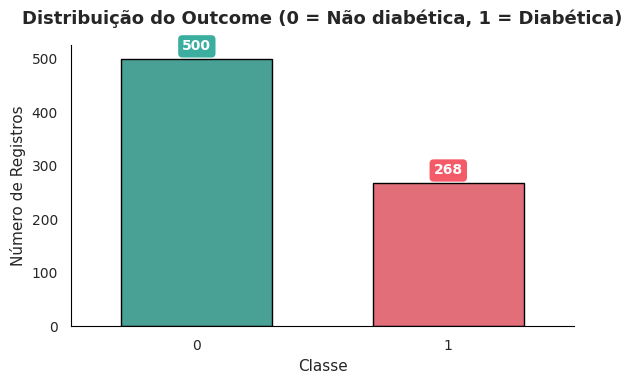

In [ ]:

# Configurações globais
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# =======================
# Gráfico de distribuição do Outcome
# =======================
fig, ax = plt.subplots(figsize=(6, 4))
bars = sns.countplot(
    x="Outcome",
    data=df,
    palette=["#3BAEA0", "#F45B69"],  # Cores suaves e contrastantes
    width=0.6,
    ax=ax,
    edgecolor="black"
)

# Adiciona rótulos sobre as barras com caixas coloridas
for p in bars.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height + 10,  # posição acima da barra
        f"{int(height)}",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold",
        color="white",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#3BAEA0" if p.get_x() < 0.5 else "#F45B69", edgecolor="none")
    )

# Título e eixos
ax.set_title("Distribuição do Outcome (0 = Não diabética, 1 = Diabética)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Classe")
ax.set_ylabel("Número de Registros")

# Remove grades e bordas laterais
sns.despine(left=False, bottom=False)
ax.grid(False)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# TABELA 2 — Estatísticas descritivas
# ============================================================

import pandas as pd
import numpy as np

# Dicionário com os nomes abreviados, como no artigo
colunas = {
    'Pregnancies': 'Preg',
    'Glucose': 'Gluc',
    'BloodPressure': 'BP',
    'SkinThickness': 'Skin',
    'Insulin': 'Insulin',
    'BMI': 'BMI',
    'DiabetesPedigreeFunction': 'DPF',
    'Age': 'Age'
}

# Selecionar as colunas
df_tabela = df[list(colunas.keys())].rename(columns=colunas)


# Calcular estatísticas
tabela_descr = pd.DataFrame({
    'Min.': df_tabela.min(),
    '1st Qu.': df_tabela.quantile(0.25),
    'Median': df_tabela.median(),
    'Mean': df_tabela.mean(),
    '3rd Qu.': df_tabela.quantile(0.75),
    'Max.': df_tabela.max()
}).T.round(2)

# Exibir tabela no formato desejado
display(tabela_descr)

# (opcional) salvar para Word ou Excel
# tabela_descr.to_excel("Tabela2_Estatisticas_Descritivas.xlsx")


,Preg,Gluc,BP,Skin,Insulin,BMI,DPF,Age
Min.,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00
1st Qu.,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00
Median,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00
Mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24
3rd Qu.,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00
Max.,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00


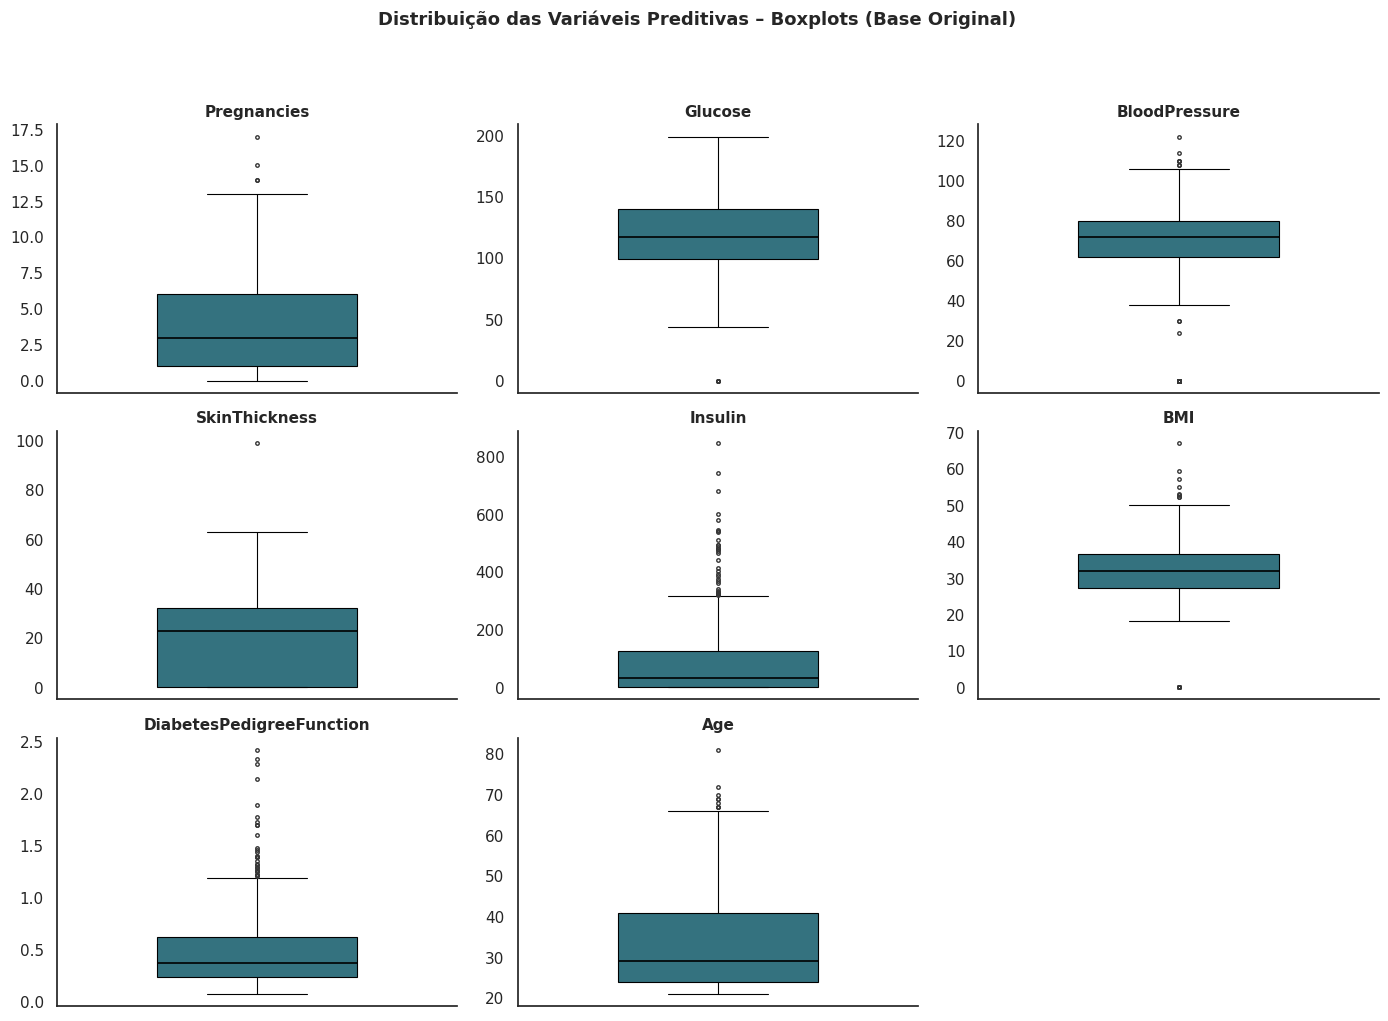

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Boxplots das variáveis preditoras – Base Original
# =========================

sns.set_theme(style="white")  # fundo branco, sem grades
cols_plot = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols_plot):
    sns.boxplot(
        y=df[col],
        color=sns.color_palette("crest")[3],
        width=0.5,
        linewidth=0.8,
        fliersize=2.5,     # tamanho reduzido dos outliers
        boxprops={'edgecolor': 'black'},
        whiskerprops={'color': 'black'},
        capprops={'color': 'black'},
        medianprops={'color': 'black', 'linewidth': 1.2},
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].grid(False)  # remove grades
    sns.despine(ax=axes[i])  # remove bordas sup. e direita

# Remove eixos extras se houver
for j in range(len(cols_plot), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribuição das Variáveis Preditivas – Boxplots (Base Original)",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


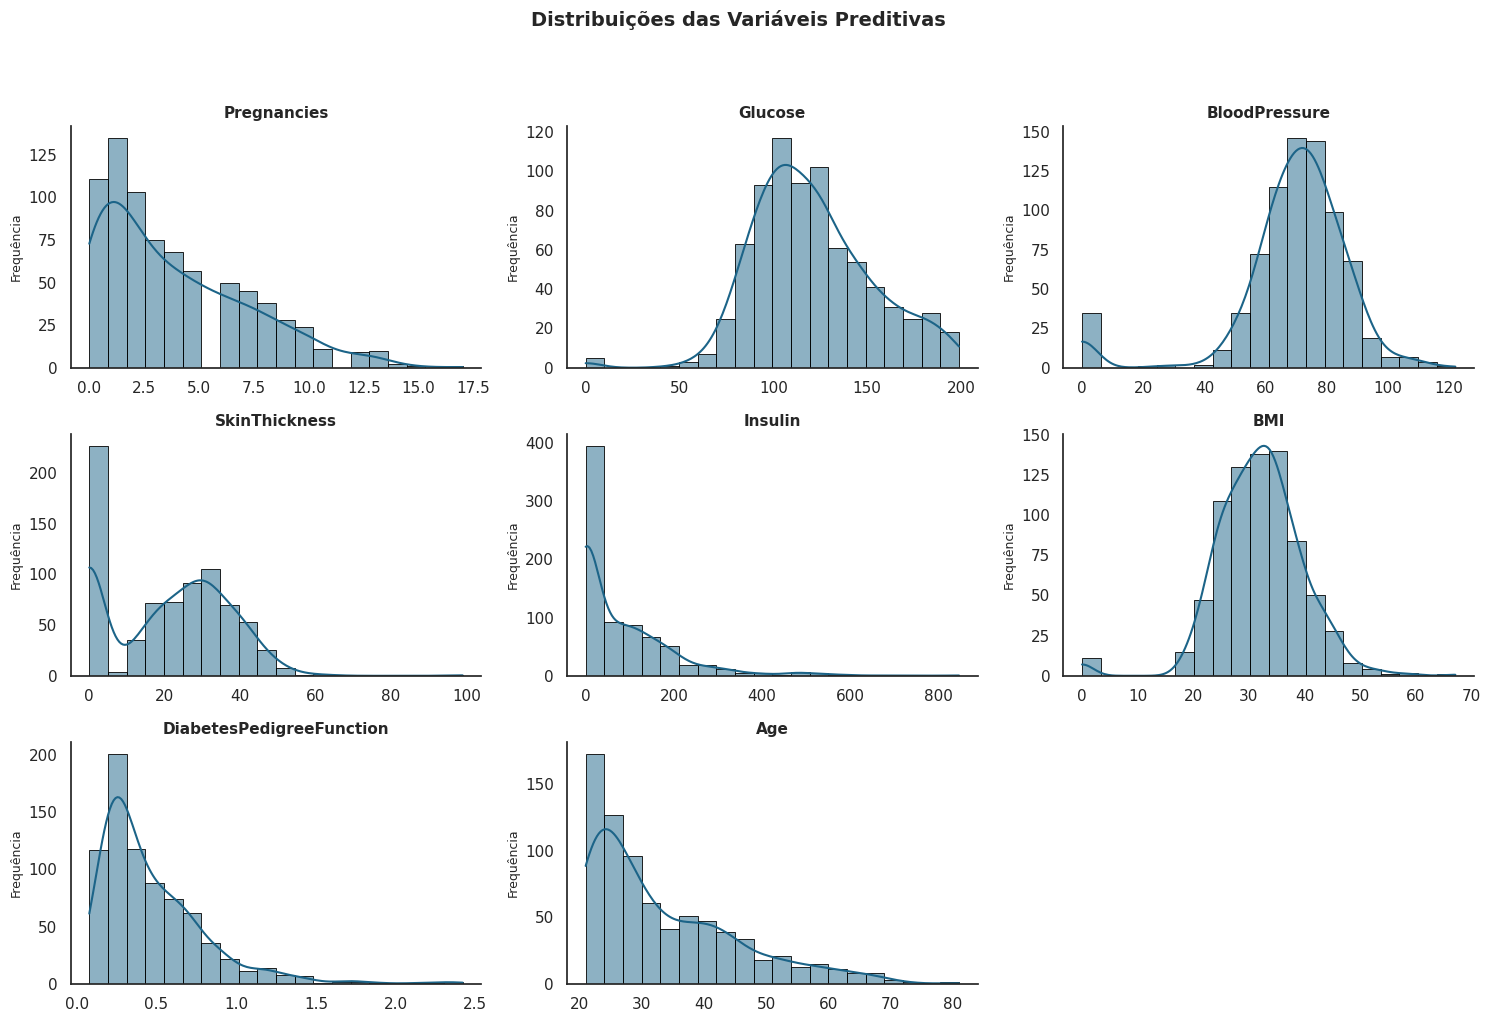

In [ ]:
# ------------------------------------------------------------
# Histogramas das variáveis preditoras
# ------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

cols_plot = ['Pregnancies', 'Glucose', 'BloodPressure',
             'SkinThickness', 'Insulin', 'BMI',
             'DiabetesPedigreeFunction', 'Age']

for i, col in enumerate(cols_plot):
    sns.histplot(
        df[col],
        bins=20,
        kde=True,
        color=sns.color_palette("crest")[4],
        edgecolor='black',
        linewidth=0.6,
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequência', fontsize=9)
    axes[i].grid(False)
    sns.despine(ax=axes[i])

fig.delaxes(axes[-1])
fig.suptitle('Distribuições das Variáveis Preditivas ',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


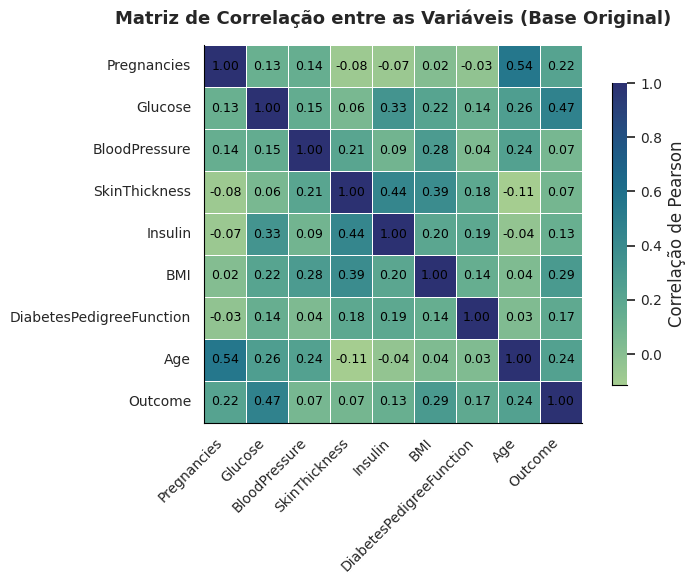

In [ ]:
# =========================
#  Matriz de Correlação
# =========================

# Cálculo da correlação
corr = df.corr(numeric_only=True)

# Estilo visual clean
sns.set_theme(style="white")
plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# Figura
fig, ax = plt.subplots(figsize=(8, 6))

# Paleta moderna, fundo branco
sns.heatmap(
    corr,
    cmap="crest",               # Paleta verde-azulada
    annot=True,                 # Mostra os valores numéricos
    fmt=".2f",                  # Duas casas decimais
    linewidths=0.6,             # Linhas divisórias finas
    cbar_kws={"shrink": 0.8, "label": "Correlação de Pearson"},
    square=True,
    annot_kws={"size": 9, "color": "black"},  # Texto legível
    ax=ax
)

# Título e estética geral
ax.set_title("Matriz de Correlação entre as Variáveis (Base Original)", fontsize=13, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()


### **4) Preparação dos dados para modelagem**

In [ ]:
# ========================= PREPARAÇÃO =========================
from typing import Tuple

def split_xy(dfin: pd.DataFrame, target: str = TARGET) -> Tuple[pd.DataFrame, pd.Series]:
    X = dfin.drop(columns=[target]).copy()
    y = dfin[target].copy()
    return X, y

def avaliar_modelo(modelo, X_train, y_train, X_test, y_test, X_full, y_full, nome_base):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = (modelo.predict_proba(X_test)[:,1]
              if hasattr(modelo, "predict_proba") else None)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    cv5 = cross_val_score(modelo, X_full, y_full, cv=5, scoring='accuracy')

    resultados = {
        "Base": nome_base,
        "Acurácia": acc,
        "Precisão": prec,
        "Recall": rec,
        "Especificidade": spec,
        "F1": f1,
        "AUC": auc,
        "CV5_Média": cv5.mean(),
        "CV5_DP": cv5.std()
    }
    return resultados, cm, y_pred

def print_relatorio(nome_base, cm, y_test, y_pred):
    print(f"\n=== {nome_base} ===")
    print("Matriz de confusão:\n", cm)
    print("\nRelatório de classificação:\n",
          classification_report(y_test, y_pred, target_names=['Não diabético','Diabético'],
                                zero_division=0))

### **5) Treinamento e ajuste de hiperparâmetros**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split

# ========================= ESCOLHA DA BASE PARA O MODELO =========================
df_treated = bases["8_MedianaCond_SMOTE"]  # ou "4_ZerosMedianaCond", etc.

# ========================= SEPARAÇÃO ENTRE TREINO E TESTE =========================
X = df_treated.drop(columns=[TARGET])
y = df_treated[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamanho dos conjuntos:")
print("Treino:", X_train.shape, " | Teste:", X_test.shape)


# ========================= RANDOM SEARCH PARA HIPERPARÂMETROS =========================

# Espaço de busca (intervalos e distribuições)
param_dist = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': randint(2, 20),               # profundidade máxima
    'min_samples_split': randint(2, 30),       # mínimo de amostras para divisão
    'min_samples_leaf': randint(1, 10),        # mínimo de amostras em folha
    'max_features': [None, 'sqrt', 'log2'],    # nº de features por divisão
    'ccp_alpha': uniform(0.0, 0.02)            # parâmetro de poda (cost-complexity)
}

# Modelo base
dt = DecisionTreeClassifier(random_state=42)

# RandomizedSearchCV — busca aleatória com 100 combinações
random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=100,                # número de combinações testadas
    scoring='accuracy',        # métrica base
    cv=10,                     # validação cruzada 10-fold
    random_state=42,
    n_jobs=-1,                 # usa todos os núcleos disponíveis
    verbose=1
)

# Treina o otimizador nos dados de treino
random_search.fit(X_train, y_train)

# Melhor modelo encontrado
best_dt = random_search.best_estimator_

print("\n=== Melhores hiperparâmetros encontrados ===")
print(random_search.best_params_)
print("Acurácia média (CV=10):", round(random_search.best_score_, 4))


Tamanho dos conjuntos:
Treino: (800, 8)  | Teste: (200, 8)
Fitting 10 folds for each of 100 candidates, totalling 1000 fits

=== Melhores hiperparâmetros encontrados ===
{'ccp_alpha': np.float64(0.002750418882919865), 'criterion': 'gini', 'max_depth': 19, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 8}
Acurácia média (CV=10): 0.8762


In [ ]:
# ========================= TREINAMENTO - Melhores hiperparametros =========================
params_fixos = {
    'criterion': 'gini',
    'max_depth': 18,
    'min_samples_split': 29,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'ccp_alpha': 0.002961738599067998,
    'random_state': RANDOM_STATE
}

### **6) Avaliação e validação do modelo**

In [ ]:
# ========================= 6. AVALIAÇÃO (8 CENÁRIOS) =========================
resultados = []
conf_mats = {}
predicoes = {}

for nome_base, dbase in bases.items():
    dbase = dbase.dropna(subset=[TARGET]).copy()  # segurança

    X, y = split_xy(dbase, target=TARGET)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    modelo = DecisionTreeClassifier(**params_fixos)

    res, cm, y_pred = avaliar_modelo(
        modelo, X_train, y_train, X_test, y_test, X, y, nome_base
    )
    resultados.append(res)
    conf_mats[nome_base] = cm
    predicoes[nome_base] = (y_test, y_pred)

    # Relatório compacto
    print_relatorio(nome_base, cm, y_test, y_pred)

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados[
    ["Base","Acurácia","Precisão","Recall","Especificidade","F1","AUC","CV5_Média","CV5_DP"]
].sort_values(by=["AUC","F1","Acurácia"], ascending=False)

print("\n=== Tabela Comparativa (ordenada por AUC, F1, Acurácia) ===")
display(df_resultados)


=== 1_Original ===
Matriz de confusão:
 [[77 23]
 [32 22]]

Relatório de classificação:
                precision    recall  f1-score   support

Não diabético       0.71      0.77      0.74       100
    Diabético       0.49      0.41      0.44        54

     accuracy                           0.64       154
    macro avg       0.60      0.59      0.59       154
 weighted avg       0.63      0.64      0.63       154


=== 2_RemovendoZeros ===
Matriz de confusão:
 [[42 11]
 [14 12]]

Relatório de classificação:
                precision    recall  f1-score   support

Não diabético       0.75      0.79      0.77        53
    Diabético       0.52      0.46      0.49        26

     accuracy                           0.68        79
    macro avg       0.64      0.63      0.63        79
 weighted avg       0.67      0.68      0.68        79


=== 3_ZerosMedia ===
Matriz de confusão:
 [[83 17]
 [26 28]]

Relatório de classificação:
                precision    recall  f1-score   support



,Base,Acurácia,Precisão,Recall,Especificidade,F1,AUC,CV5_Média,CV5_DP
7,8_MedianaCond_SMOTE,0.905000,0.893204,0.920000,0.890000,0.906404,0.917900,0.873000,0.029086
3,4_ZerosMedianaCond,0.857143,0.833333,0.740741,0.920000,0.784314,0.906481,0.864587,0.014423
6,7_MICE_SMOTE,0.750000,0.765957,0.720000,0.780000,0.742268,0.786400,0.754000,0.044654
1,2_RemovendoZeros,0.683544,0.521739,0.461538,0.792453,0.489796,0.762700,0.745083,0.043723
2,3_ZerosMedia,0.720779,0.622222,0.518519,0.830000,0.565657,0.761667,0.695314,0.023747
4,5_MICE,0.662338,0.520000,0.481481,0.760000,0.500000,0.730741,0.726602,0.028991
5,6_MICE_Normalizado,0.662338,0.520000,0.481481,0.760000,0.500000,0.730741,0.726602,0.028991
0,1_Original,0.642857,0.488889,0.407407,0.770000,0.444444,0.681944,0.738307,0.027543


### **7) Interpretação e análise dos resultados**

Melhor base por critérios (AUC > F1 > Acurácia): 8_MedianaCond_SMOTE


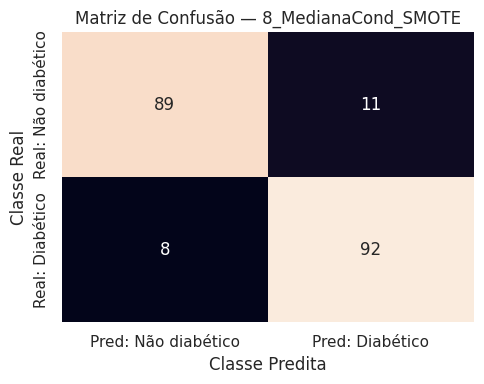

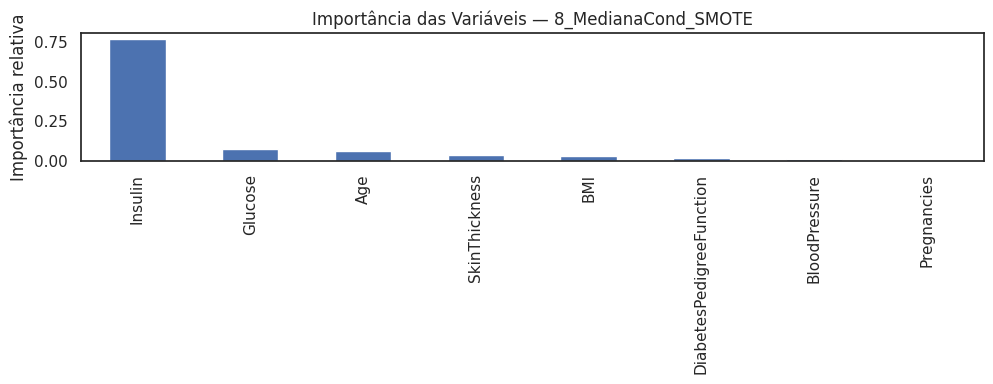

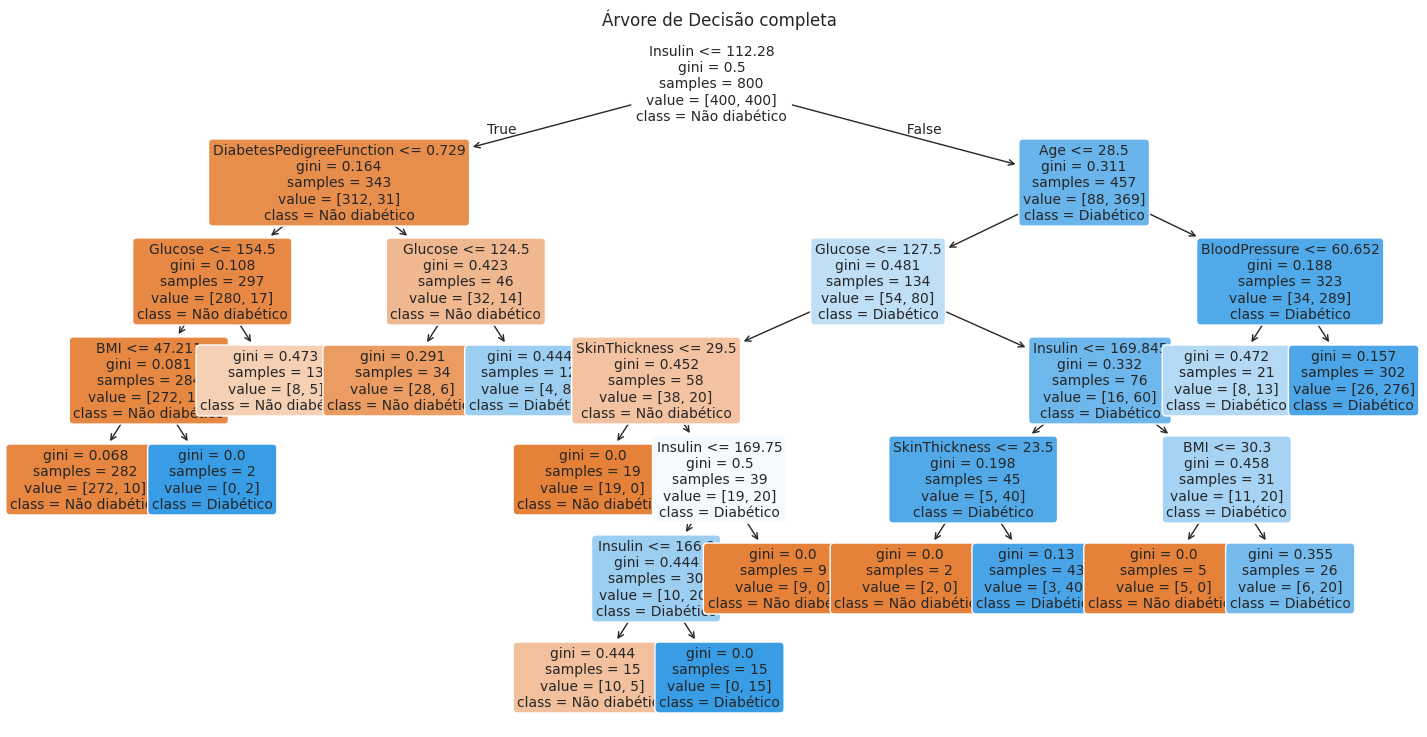

In [ ]:
# ========================= 7. INTERPRETAÇÃO =========================
# Escolha por maior AUC; em caso de empate, F1 e depois Acurácia
ord_cols = ["AUC","F1","Acurácia"]
melhor_idx = df_resultados.sort_values(by=ord_cols, ascending=False).index[0]
melhor_base = df_resultados.loc[melhor_idx, "Base"]
print("Melhor base por critérios (AUC > F1 > Acurácia):", melhor_base)

# Reconstruir splits dessa base
dbase = bases[melhor_base].dropna(subset=[TARGET]).copy()
X, y = split_xy(dbase, target=TARGET)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

modelo_final = DecisionTreeClassifier(**params_fixos)
modelo_final.fit(X_train, y_train)
y_pred = modelo_final.predict(X_test)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=['Pred: Não diabético','Pred: Diabético'],
            yticklabels=['Real: Não diabético','Real: Diabético'])
plt.title(f'Matriz de Confusão — {melhor_base}')
plt.xlabel('Classe Predita'); plt.ylabel('Classe Real')
plt.tight_layout(); plt.show()

# Importância das variáveis
importances = pd.Series(modelo_final.feature_importances_, index=X.columns).sort_values(ascending=False)
ax = importances.plot(kind='bar', figsize=(10,4))
ax.set_title(f'Importância das Variáveis — {melhor_base}')
ax.set_ylabel('Importância relativa')
plt.tight_layout(); plt.show()

# Árvore (até 3 níveis para legibilidade)
plt.figure(figsize=(18, 9))
plot_tree(
    modelo_final,
    feature_names=X.columns,
    class_names=['Não diabético','Diabético'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Árvore de Decisão completa")
plt.show()

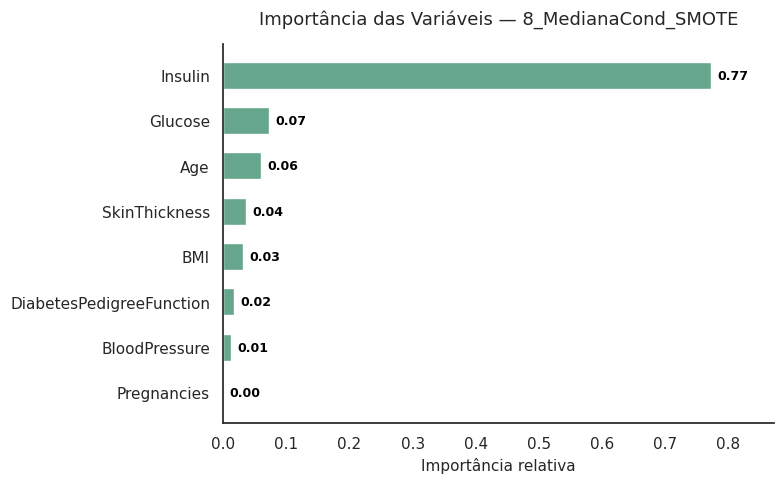

In [ ]:
# ========================= Importância das Variáveis — Barras Horizontais com Rótulos =========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Série de importância (ordem decrescente)
importances = (
    pd.Series(modelo_final.feature_importances_, index=X.columns)
    .sort_values(ascending=True)  # ascending=True para o menor embaixo e o maior no topo
)

# Estilo visual
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    importances.index,
    importances.values,
    color="#65A68C",       # verde-oliva
    #edgecolor="black",
    height=0.6
)

# Adiciona rótulos nas barras
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,                   # deslocamento à direita da barra
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        ha="left", va="center",
        fontsize=9, fontweight="semibold", color="black"
    )

# Estética geral
ax.set_title(f"Importância das Variáveis — {melhor_base}", fontsize=13, pad=15)
ax.set_xlabel("Importância relativa", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, importances.max() + 0.1)
ax.grid(False)
sns.despine()

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.tree import export_text

# Gera a árvore completa em formato textual
tree_rules = export_text(modelo_final, feature_names=list(X.columns), decimals=3)

# Exibe na tela
print(tree_rules)


|--- Insulin <= 112.280
|   |--- DiabetesPedigreeFunction <= 0.729
|   |   |--- Glucose <= 154.500
|   |   |   |--- BMI <= 47.211
|   |   |   |   |--- class: 0
|   |   |   |--- BMI >  47.211
|   |   |   |   |--- class: 1
|   |   |--- Glucose >  154.500
|   |   |   |--- class: 0
|   |--- DiabetesPedigreeFunction >  0.729
|   |   |--- Glucose <= 124.500
|   |   |   |--- class: 0
|   |   |--- Glucose >  124.500
|   |   |   |--- class: 1
|--- Insulin >  112.280
|   |--- Age <= 28.500
|   |   |--- Glucose <= 127.500
|   |   |   |--- SkinThickness <= 29.500
|   |   |   |   |--- class: 0
|   |   |   |--- SkinThickness >  29.500
|   |   |   |   |--- Insulin <= 169.750
|   |   |   |   |   |--- Insulin <= 166.000
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Insulin >  166.000
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- Insulin >  169.750
|   |   |   |   |   |--- class: 0
|   |   |--- Glucose >  127.500
|   |   |   |--- Insulin <= 169.845
|   |   |   |   |--- Skin